Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


1. Loading Data and Building Simple Time Windows

In [ ]:
claims = pd.read_csv("cleaned_claims.csv")
staging = pd.read_csv("cleaned_staging.csv")

df = claims.merge(staging, on="member_number", how="inner")

# engineer anchor date
df["days_from_stage"] = df["days_since_earliest_dt"] - df["most_recent_stage_date"] 

In [3]:
# breast only
breast = df[df["cancer_type"] == "breast"].copy()

In [4]:
# simple time windows
breast["stage_time_window"] = np.select(
    [
        breast["days_from_stage"] < 0,
        breast["days_from_stage"].between(0, 90),
        breast["days_from_stage"] > 90
    ],
    ["pre_stage", "0_to_90", "post_90"],
    default=np.nan
)

In [5]:
# column groupings
stage_order = ["I", "II", "III", "IV"]
window_order = ["pre_stage", "0_to_90", "post_90"]
driver_cols = ["DRUG_NM", "HCPCS", "PROC_DESC", "provider_number"]

In [6]:
# column type enforcement
breast["final_stage_simple"] = pd.Categorical(
    breast["final_stage_simple"], categories=stage_order, ordered=True
)
breast["stage_time_window"] = pd.Categorical(
    breast["stage_time_window"], categories=window_order, ordered=True
)

In [7]:
# claim type separation
cohorts = {
    "all_claims": breast,
    "cancer_related": breast[breast["is_cancer_related"]].copy()
}

2. Cohort Checks

In [8]:
# quick cohort check
print("Breast claims:", breast.shape)
print("Breast patients:", breast["member_number"].nunique())

print("\nBreast patients by stage:")
display(
    breast[["member_number", "final_stage_simple"]]
    .drop_duplicates()["final_stage_simple"]
    .value_counts()
    .sort_index()
)

print("\nClaims by time window:")
display(breast["stage_time_window"].value_counts(dropna=False).sort_index())

Breast claims: (1357984, 31)
Breast patients: 2041

Breast patients by stage:


final_stage_simple
I      1416
II      375
III     140
IV      110
Name: count, dtype: int64


Claims by time window:


stage_time_window
pre_stage    353171
0_to_90      159198
post_90      845615
Name: count, dtype: int64

3. Helper Functions for Driver Summaries

In [ ]:
def summarize_driver(df, col, by_time=False, top_n=10):
    """
Summarizes a cost driver column by stage and optionally by time window.
Filters out invalid entries and calculates various cost metrics, shares, and ranks.
    """
    temp = df.copy()
    temp[col] = temp[col].astype(str).str.strip()
    temp = temp[
        temp[col].notna() &
        (temp[col] != "") &
        (temp[col].str.upper() != "NAN")
    ].copy()

    group_cols = ["final_stage_simple", col]
    if by_time:
        temp = temp[temp["stage_time_window"].notna()].copy()
        group_cols = ["final_stage_simple", "stage_time_window", col]

    out = (
        temp.groupby(group_cols, observed=False)
        .agg(
            n_claims=("member_number", "size"),
            n_patients=("member_number", "nunique"),
            total_cost=("c_allowed", "sum"),
            total_util=("C_UTIL_CT", "sum"),
            mean_claim_cost=("c_allowed", "mean"),
            median_claim_cost=("c_allowed", "median")
        )
        .reset_index()
    )

    out["cost_per_patient"] = out["total_cost"] / out["n_patients"]
    out["claims_per_patient"] = out["n_claims"] / out["n_patients"]

    total_cols = ["final_stage_simple"]
    share_name = "cost_share_within_stage"
    rank_name = "rank"

    if by_time:
        total_cols = ["final_stage_simple", "stage_time_window"]
        share_name = "cost_share_within_window"

    totals = (
        temp.groupby(total_cols, observed=False)["c_allowed"]
        .sum()
        .rename("group_total_cost")
        .reset_index()
    )

    out = out.merge(totals, on=total_cols, how="left")
    out[share_name] = out["total_cost"] / out["group_total_cost"]

    out[rank_name] = (
        out.groupby(total_cols, observed=False)["total_cost"]
        .rank(method="first", ascending=False)
    )

    return out[out[rank_name] <= top_n].sort_values(total_cols + [rank_name]).reset_index(drop=True)

In [11]:
def show_top(summary_df, col, by_time=False, top_k=10):
    """
    Displays the top cost drivers from the summary DataFrame, grouped by stage and optionally by time window.
    Shows key metrics for each driver, including counts, costs, shares, and ranks.
    """
    for stage in stage_order:
        if by_time:
            print(f"\nStage {stage}")
            for window in window_order:
                print(f"  {window}")
                display(
                    summary_df[
                        (summary_df["final_stage_simple"] == stage) &
                        (summary_df["stage_time_window"] == window)
                    ][[
                        col, "n_claims", "n_patients", "total_cost",
                        "cost_per_patient", "mean_claim_cost"
                    ]].head(top_k)
                )
        else:
            print(f"\nStage {stage}")
            display(
                summary_df[summary_df["final_stage_simple"] == stage][[
                    col, "n_claims", "n_patients", "total_cost",
                    "cost_per_patient", "mean_claim_cost"
                ]].head(top_k)
            )

In [18]:
def make_presence_matrix(summary_df, col):
    mat = (
        summary_df[
            [c for c in summary_df.columns if c in ["final_stage_simple", "stage_time_window", col, "rank"]]
        ]
        .assign(hit=1)
        .pivot_table(
            index=col,
            columns=["final_stage_simple", "stage_time_window"],
            values="hit",
            fill_value=0
        )
    )

    mat["n_hits"] = mat.sum(axis=1)
    mat = mat.sort_values("n_hits", ascending=False)

    yesno = mat.copy().astype(object)
    yesno.iloc[:, :-1] = yesno.iloc[:, :-1].map(lambda x: "Yes" if x == 1 else "No")

    return mat, yesno

In [20]:
def plot_heatmap(mat, title="", top_n=20, figsize=(12, 6)):
    """
    Plots a heatmap of the presence matrix for cost drivers across stages and time windows.
    Displays the top N drivers based on the number of hits, with color intensity indicating presence.
    """
    x = mat.drop(columns="n_hits").head(top_n)

    plt.figure(figsize=figsize)
    plt.imshow(x.values, aspect="auto")
    plt.colorbar()
    plt.xticks(
        np.arange(len(x.columns)),
        [f"{a}\n{b}" for a, b in x.columns],
        rotation=45,
        ha="right"
    )
    plt.yticks(np.arange(len(x.index)), x.index)
    plt.title(title)
    plt.tight_layout()
    plt.show()

4. Print Out Summaries

In [10]:
# build all summaries in one place
overall = {
    cohort: {col: summarize_driver(df, col, by_time=False, top_n=10) for col in driver_cols}
    for cohort, df in cohorts.items()
}

time_aware = {
    cohort: {col: summarize_driver(df, col, by_time=True, top_n=10) for col in driver_cols}
    for cohort, df in cohorts.items()
}

In [17]:
# example usage
show_top(time_aware["cancer_related"]["DRUG_NM"], "DRUG_NM", by_time=True)


Stage I
  pre_stage


,DRUG_NM,n_claims,n_patients,total_cost,cost_per_patient,mean_claim_cost
0,VERZENIO,2,1,27276.480000,27276.480000,13638.240000
1,ANASTROZOLE,145,32,2658.706652,83.084583,18.335908
2,TAMOXIFEN CITRATE,37,8,1145.540000,143.192500,30.960541
3,EXEMESTANE,4,3,570.260274,190.086758,142.565069
4,VANCOMYCIN HCL,1,1,430.070000,430.070000,430.070000
5,DEXAMETHASONE,23,12,262.345879,21.862157,11.406343
6,PROCHLORPERAZINE MALEA,14,11,242.286465,22.026042,17.306176
7,LETROZOLE,10,4,188.800000,47.200000,18.880000
8,LIDOCAINE HCL VISCOUS,8,1,146.100000,146.100000,18.262500
9,LIDOCAINE-PRILOCAINE,5,5,87.850021,17.570004,17.570004


  0_to_90


,DRUG_NM,n_claims,n_patients,total_cost,cost_per_patient,mean_claim_cost
10,VERZENIO,1,1,13638.240000,13638.240000,13638.240000
11,ANASTROZOLE,173,99,2820.657529,28.491490,16.304379
12,CAPECITABINE,1,1,2681.350000,2681.350000,2681.350000
13,EXEMESTANE,6,4,1598.405570,399.601392,266.400928
14,PROCHLORPERAZINE MALEA,58,44,1155.988584,26.272468,19.930838
15,DEXAMETHASONE,72,40,1149.842317,28.746058,15.970032
16,TAMOXIFEN CITRATE,38,21,989.947768,47.140370,26.051257
17,LINZESS,2,1,942.900000,942.900000,471.450000
18,LETROZOLE,16,8,269.773704,33.721713,16.860856
19,LIDOCAINE-PRILOCAINE,8,7,183.152811,26.164687,22.894101


  post_90


...

,DRUG_NM,n_claims,n_patients,total_cost,cost_per_patient,mean_claim_cost
90,IBRANCE,60,4,697822.750000,174455.687500,11630.379167
91,VERZENIO,1,1,11181.930000,11181.930000,11181.930000
92,LETROZOLE,14,3,275.542767,91.847589,19.681626
93,EXEMESTANE,1,1,171.920000,171.920000,171.920000
94,PROCHLORPERAZINE MALEA,7,6,109.810000,18.301667,15.687143
95,ONDANSETRON ODT,3,1,109.760005,109.760005,36.586668
96,ANASTROZOLE,7,2,101.400000,50.700000,14.485714
97,OXYCODONE-ACETAMINOPHE,5,1,72.400116,72.400116,14.480023
98,LOPERAMIDE,1,1,35.590002,35.590002,35.590002
99,MORPHINE SULFATE ER,1,1,22.550000,22.550000,22.550000


  0_to_90


,DRUG_NM,n_claims,n_patients,total_cost,cost_per_patient,mean_claim_cost
100,IBRANCE,21,7,246029.910000,35147.130000,11715.710000
101,VERZENIO,6,2,74419.890000,37209.945000,12403.315000
102,KISQALI,1,1,18368.753702,18368.753702,18368.753702
103,CAPECITABINE,3,1,1899.290000,1899.290000,633.096667
104,EXEMESTANE,3,1,803.970000,803.970000,267.990000
105,LETROZOLE,12,6,275.250000,45.875000,22.937500
106,PROCHLORPERAZINE MALEA,13,5,223.870000,44.774000,17.220769
107,ANASTROZOLE,9,4,104.430000,26.107500,11.603333
108,MORPHINE SULFATE ER,4,2,83.630000,41.815000,20.907500
109,OXYCODONE-ACETAMINOPHE,4,2,60.270154,30.135077,15.067538


  post_90


,DRUG_NM,n_claims,n_patients,total_cost,cost_per_patient,mean_claim_cost
110,IBRANCE,180,11,2.100567e+06,190960.640000,11669.816889
111,NERLYNX,45,1,6.834590e+05,683458.990000,15187.977556
112,VERZENIO,29,4,3.631249e+05,90781.217106,12521.547187
113,EVEROLIMUS,4,1,4.071280e+04,40712.800000,10178.200000
114,AFINITOR,2,1,1.439510e+04,14395.100000,7197.550000
115,CAPECITABINE,19,1,1.273646e+04,12736.460000,670.340000
116,LETROZOLE,231,10,5.385857e+03,538.585662,23.315397
117,EXEMESTANE,21,5,3.669410e+03,733.881944,174.733796
118,ANASTROZOLE,76,11,1.088135e+03,98.921382,14.317568
119,ELIQUIS,2,1,1.027880e+03,1027.880000,513.940000


In [19]:
drug_mat_num, drug_mat_yesno = make_presence_matrix(time_aware["cancer_related"]["DRUG_NM"], "DRUG_NM")
display(drug_mat_yesno.head(20))

final_stage_simple             I                        II                  \
stage_time_window      pre_stage 0_to_90 post_90 pre_stage 0_to_90 post_90   
DRUG_NM                                                                      
LETROZOLE                    Yes     Yes     Yes       Yes     Yes     Yes   
ANASTROZOLE                  Yes     Yes     Yes       Yes      No     Yes   
EXEMESTANE                   Yes     Yes     Yes       Yes      No     Yes   
PROCHLORPERAZINE MALEA       Yes     Yes      No       Yes     Yes      No   
VERZENIO                     Yes     Yes     Yes        No      No     Yes   
IBRANCE                       No      No      No        No      No     Yes   
CAPECITABINE                  No     Yes      No       Yes     Yes     Yes   
TAMOXIFEN CITRATE            Yes     Yes     Yes       Yes     Yes     Yes   
DEXAMETHASONE                Yes     Yes      No       Yes     Yes      No   
POTASSIUM CHLORIDE            No      No      No       Yes     Yes     Yes   
LIDOCAINE-PRILOCAINE         Yes     Yes      No        No      No      No   
MORPHINE SULFATE ER           No      No      No        No      No      No   
NEUPOGEN                      No      No      No        No     Yes     Yes   
KISQALI                       No      No     Yes        No      No      No   
ELIQUIS                       No      No      No        No      No     Yes   
SUCRALFATE                    No      No      No        No      No      No   
LUPRON DEPOT                  No      No     Yes        No     Yes      No   
OXYCODONE-ACETAMINOPHE        No      No      No        No      No      No   
VEOZAH                        No      No     Yes        No      No      No   
VENLAFAXINE HCL               No      No      No        No      No      No   

final_stage_simple           III                        IV                  \
stage_time_window      pre_stage 0_to_90 post_90 pre_stage 0_to_90 post_90   
DRUG_NM                                                                      
LETROZOLE                    Yes     Yes     Yes       Yes     Yes     Yes   
ANASTROZOLE                  Yes     Yes     Yes       Yes     Yes     Yes   
EXEMESTANE                   Yes     Yes     Yes       Yes     Yes     Yes   
PROCHLORPERAZINE MALEA       Yes     Yes     Yes       Yes     Yes      No   
VERZENIO                      No      No     Yes       Yes     Yes     Yes   
IBRANCE                      Yes     Yes     Yes       Yes     Yes     Yes   
CAPECITABINE                  No      No     Yes        No     Yes     Yes   
TAMOXIFEN CITRATE            Yes      No      No        No      No      No   
DEXAMETHASONE                Yes     Yes      No        No      No      No   
POTASSIUM CHLORIDE            No      No      No        No      No      No   
LIDOCAINE-PRILOCAINE          No     Yes      No        No      No      No   
MORPHINE SULFATE ER           No      No      No       Yes     Yes      No   
NEUPOGEN                      No      No      No        No      No      No   
KISQALI                       No      No      No        No     Yes      No   
ELIQUIS                       No      No      No        No      No     Yes   
SUCRALFATE                    No     Yes     Yes        No      No      No   
LUPRON DEPOT                  No      No      No        No      No      No   
OXYCODONE-ACETAMINOPHE        No      No      No       Yes     Yes      No   
VEOZAH                        No      No      No        No      No      No   
VENLAFAXINE HCL              Yes      No      No        No      No      No   

final_stage_simple     n_hits  
stage_time_window              
DRUG_NM                        
LETROZOLE                12.0  
ANASTROZOLE              11.0  
EXEMESTANE               11.0  
PROCHLORPERAZINE MALEA    9.0  
VERZENIO                  8.0  
IBRANCE                   7.0  
CAPECITABINE              7.0  
TAMOXIFEN CITRATE         7.0  
DEXAMETHASONE             6.0  
POTASSIUM CHLORIDE        

final_stage_simple         I                        II                  \
stage_time_window  pre_stage 0_to_90 post_90 pre_stage 0_to_90 post_90   
DRUG_NM                                                                  
ELIQUIS                  Yes     Yes     Yes       Yes     Yes     Yes   
VERZENIO                  No     Yes     Yes        No      No     Yes   
IBRANCE                   No      No      No        No      No     Yes   
OZEMPIC                  Yes      No     Yes        No     Yes     Yes   
KISQALI                   No     Yes     Yes        No      No      No   
TRULICITY                Yes     Yes     Yes        No      No     Yes   
XARELTO                   No     Yes      No        No      No      No   
VICTOZA 3-PAK            Yes      No      No       Yes      No      No   
JAKAFI                   Yes     Yes     Yes        No      No      No   
RINVOQ                   Yes     Yes      No        No      No      No   
PROMACTA                 Yes     Yes     Yes        No      No      No   
ENOXAPARIN SODIUM         No      No      No        No      No      No   
TRUQAP                    No      No      No        No      No      No   
LATUDA                    No      No      No       Yes     Yes      No   
TRELEGY ELLIPTA           No      No      No        No      No      No   

final_stage_simple       III                        IV                 n_hits  
stage_time_window  pre_stage 0_to_90 post_90 pre_stage 0_to_90 post_90         
DRUG_NM                                                                        
ELIQUIS                   No     Yes     Yes        No     Yes     Yes   10.0  
VERZENIO                  No     Yes     Yes       Yes     Yes     Yes    8.0  
IBRANCE                  Yes     Yes     Yes       Yes     Yes     Yes    7.0  
OZEMPIC                  Yes     Yes     Yes        No      No      No    7.0  
KISQALI                   No      No     Yes       Yes     Yes     Yes    6.0  
TRULICITY                Yes      No      No        No      No      No    5.0  
XARELTO                  Yes     Yes      No       Yes     Yes      No    5.0  
VICTOZA 3-PAK             No      No      No       Yes     Yes      No    4.0  
JAKAFI                    No      No      No        No      No      No    3.0  
RINVOQ                   Yes      No      No        No      No      No    3.0  
PROMACTA                  No      No      No        No      No      No    3.0  
ENOXAPARIN SODIUM         No     Yes      No       Yes     Yes      No    3.0  
TRUQAP                    No      No     Yes        No      No     Yes    2.0  
LATUDA                    No      No      No        No      No      No    2.0  
TRELEGY ELLIPTA           No     Yes     Yes        No      No      No    2.0

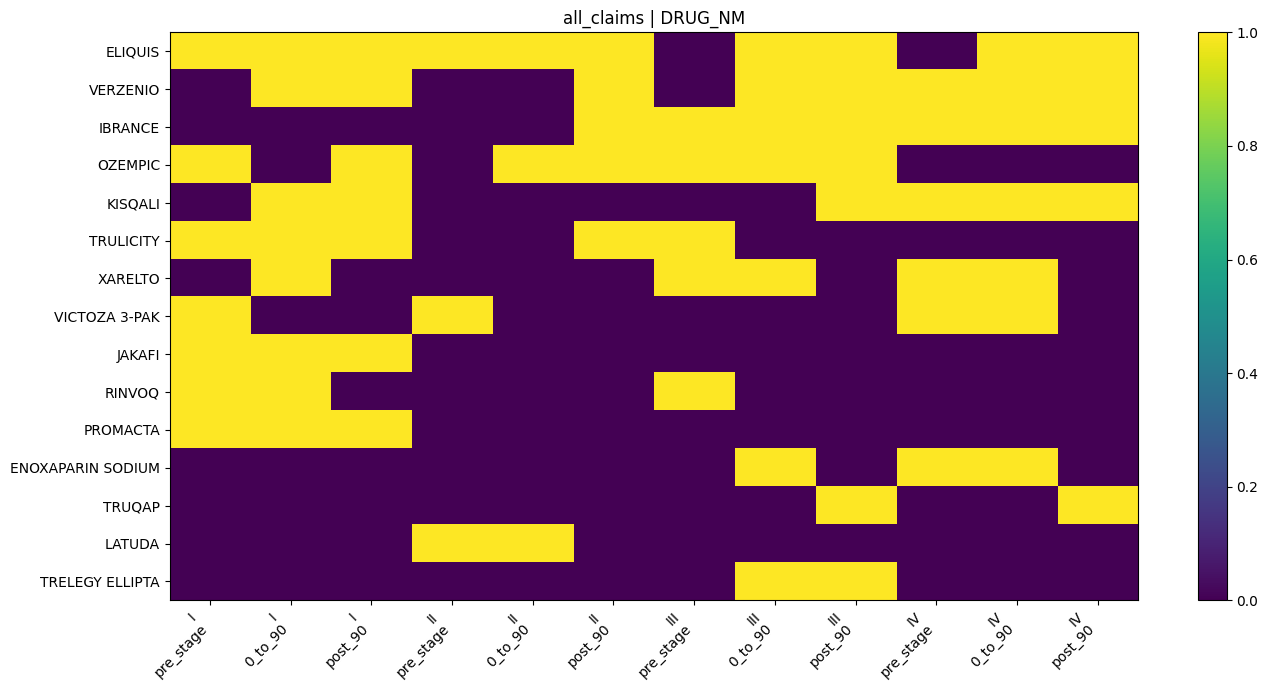

final_stage_simple         I                        II                  \
stage_time_window  pre_stage 0_to_90 post_90 pre_stage 0_to_90 post_90   
HCPCS                                                                    
J9306                    Yes     Yes     Yes       Yes     Yes     Yes   
J9355                    Yes     Yes     Yes       Yes     Yes     Yes   
J2505                    Yes     Yes     Yes       Yes     Yes     Yes   
96413                     No      No      No       Yes     Yes     Yes   
J9271                     No      No     Yes       Yes     Yes     Yes   
36561                     No     Yes      No       Yes     Yes      No   
J9354                     No      No     Yes        No      No     Yes   
J9264                     No      No      No        No      No      No   
J0897                     No      No     Yes        No      No      No   
99214                    Yes      No     Yes       Yes      No     Yes   
J1950                     No      No     Yes        No      No     Yes   
38525                    Yes     Yes      No       Yes      No      No   
19357                    Yes      No      No        No      No     Yes   
J2506                     No      No      No        No     Yes      No   
J9395                     No      No      No        No      No      No   

final_stage_simple       III                        IV                 n_hits  
stage_time_window  pre_stage 0_to_90 post_90 pre_stage 0_to_90 post_90         
HCPCS                                                                          
J9306                    Yes     Yes     Yes       Yes     Yes     Yes   12.0  
J9355                    Yes     Yes     Yes       Yes     Yes     Yes   12.0  
J2505                    Yes     Yes      No       Yes     Yes      No   10.0  
96413                    Yes     Yes     Yes       Yes     Yes     Yes    9.0  
J9271                    Yes     Yes     Yes       Yes      No      No    8.0  
36561                    Yes     Yes      No        No     Yes      No    6.0  
J9354                    Yes      No     Yes       Yes      No     Yes    6.0  
J9264                    Yes     Yes     Yes       Yes      No     Yes    5.0  
J0897                     No      No     Yes       Yes     Yes     Yes    5.0  
99214                     No      No      No        No      No      No    4.0  
J1950                     No      No     Yes        No      No      No    3.0  
38525                     No      No      No        No      No      No    3.0  
19357                     No     Yes      No        No      No      No    3.0  
J2506                    Yes     Yes      No        No      No      No    3.0  
J9395                     No      No      No       Yes     Yes     Yes    3.0

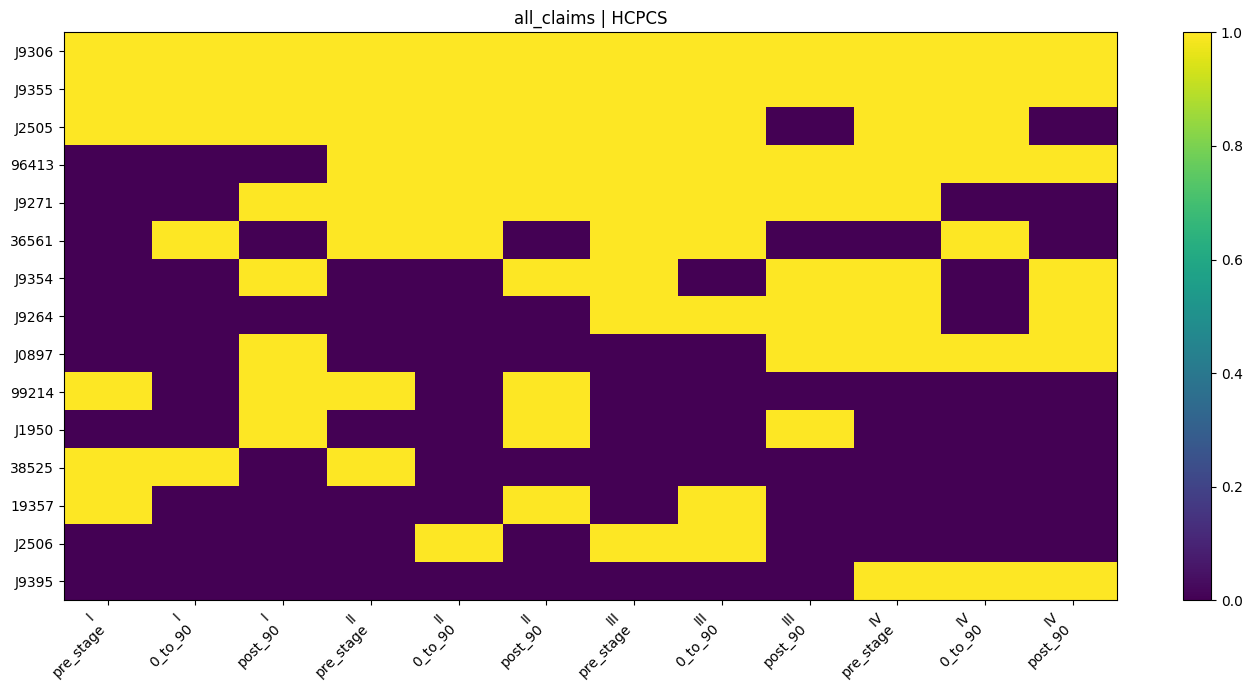

final_stage_simple                   I                        II          \
stage_time_window            pre_stage 0_to_90 post_90 pre_stage 0_to_90   
PROC_DESC                                                                  
TRASTUZUMAB INJECTION              Yes     Yes     Yes       Yes     Yes   
INJECTION, PERTUZUMAB, 1 MG        Yes     Yes     Yes       Yes     Yes   
INJECTION, PEGFILGRASTIM 6MG       Yes     Yes     Yes       Yes     Yes   
CHEMO IV INFUSION 1 HR              No      No      No       Yes     Yes   
OFFICE/OUTPATIENT VISIT EST        Yes      No     Yes       Yes      No   
INJ PEMBROLIZUMAB                   No      No     Yes       Yes     Yes   
RADIATION TREATMENT DELIVERY        No     Yes      No        No     Yes   
INSERT TUNNELED CV CATH             No     Yes      No       Yes     Yes   
INJ, ADO-TRASTUZUMAB EMT 1MG        No      No     Yes        No      No   
DENOSUMAB INJECTION                 No      No     Yes        No      No   
PACLITAXEL PROTEIN BOUND            No      No      No        No      No   
BREAST RECONSTRUCTION              Yes      No      No        No      No   
LEUPROLIDE ACETATE /3.75 MG         No      No     Yes        No      No   
BIOPSY/REMOVAL LYMPH NODES         Yes     Yes      No       Yes      No   
INJECTION, FULVESTRANT              No      No      No        No      No   

final_stage_simple                         III                        IV  \
stage_time_window            post_90 pre_stage 0_to_90 post_90 pre_stage   
PROC_DESC                                                                  
TRASTUZUMAB INJECTION            Yes       Yes     Yes     Yes       Yes   
INJECTION, PERTUZUMAB, 1 MG      Yes       Yes     Yes     Yes       Yes   
INJECTION, PEGFILGRASTIM 6MG     Yes       Yes     Yes      No       Yes   
CHEMO IV INFUSION 1 HR           Yes       Yes     Yes     Yes       Yes   
OFFICE/OUTPATIENT VISIT EST      Yes       Yes      No     Yes       Yes   
INJ PEMBROLIZUMAB                Yes       Yes     Yes     Yes        No   
RADIATION TREATMENT DELIVERY     Yes        No     Yes     Yes        No   
INSERT TUNNELED CV CATH           No       Yes     Yes      No        No   
INJ, ADO-TRASTUZUMAB EMT 1MG     Yes       Yes      No     Yes       Yes   
DENOSUMAB INJECTION               No        No      No     Yes       Yes   
PACLITAXEL PROTEIN BOUND          No       Yes      No     Yes       Yes   
BREAST RECONSTRUCTION            Yes        No     Yes      No        No   
LEUPROLIDE ACETATE /3.75 MG      Yes        No      No     Yes        No   
BIOPSY/REMOVAL LYMPH NODES        No        No      No      No        No   
INJECTION, FULVESTRANT            No        No      No      No       Yes   

final_stage_simple                           n_hits  
stage_time_window            0_to_90 post_90         
PROC_DESC                                            
TRASTUZUMAB INJECTION            Yes     Yes   12.0  
INJECTION, PERTUZUMAB, 1 MG      Yes     Yes   12.0  
INJECTION, PEGFILGRASTIM 6MG     Yes      No   10.0  
CHEMO IV INFUSION 1 HR           Yes     Yes    9.0  
OFFICE/OUTPATIENT VISIT EST       No     Yes    8.0  
INJ PEMBROLIZUMAB                 No      No    7.0  
RADIATION TREATMENT DELIVERY     Yes      No    6.0  
INSERT TUNNELED CV CATH          Yes      No    6.0  
INJ, ADO-TRASTUZUMAB EMT 1MG      No     Yes    6.0  
DENOSUMAB INJECTION              Yes     Yes    5.0  
PACLITAXEL PROTEIN BOUND          No     Yes    4.0  
BREAST RECONSTRUCTION             No      No    3.0  
LEUPROLIDE ACETATE /3.75 MG       No      No    3.0  
BIOPSY/REMOVAL LYMPH NODES        No      No    3.0  
INJECTION, FULVESTRANT           Yes     Yes    3.0

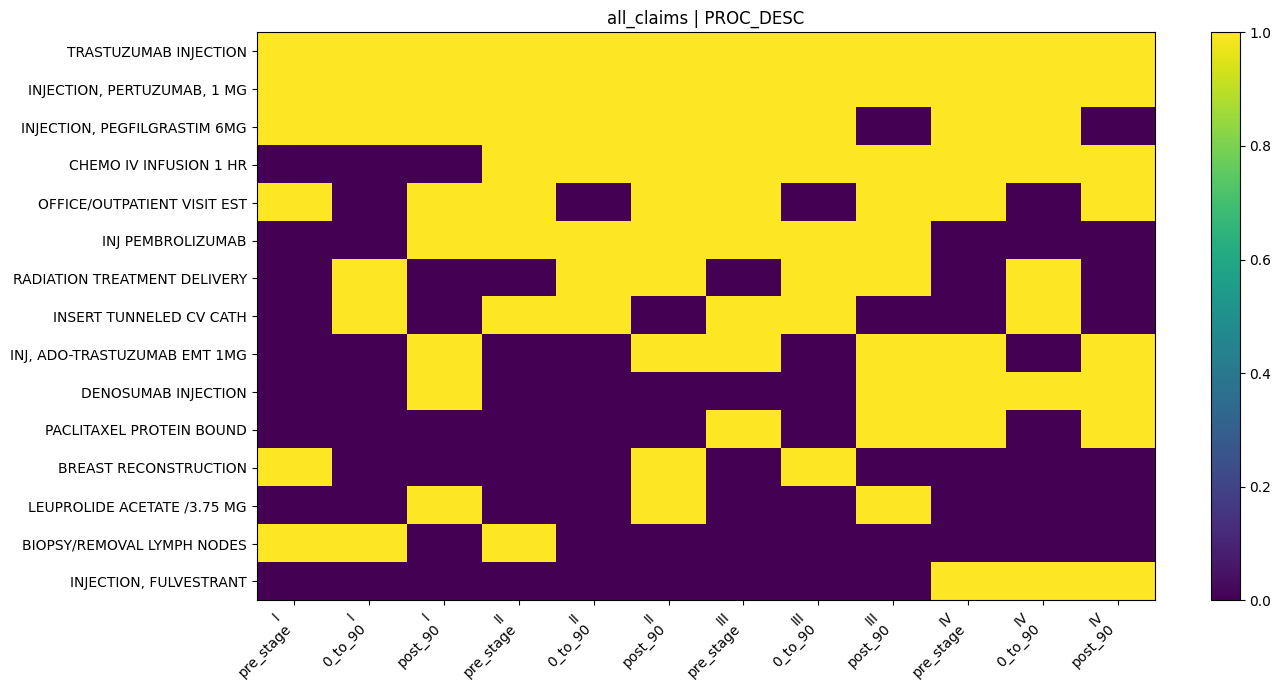

final_stage_simple         I                        II                  \
stage_time_window  pre_stage 0_to_90 post_90 pre_stage 0_to_90 post_90   
provider_number                                                          
2236.0                   Yes     Yes     Yes       Yes     Yes     Yes   
2244.0                   Yes     Yes     Yes       Yes     Yes     Yes   
2283.0                   Yes     Yes     Yes       Yes      No     Yes   
2281.0                   Yes     Yes     Yes       Yes     Yes     Yes   
2223.0                   Yes     Yes     Yes       Yes     Yes     Yes   
2228.0                   Yes     Yes     Yes       Yes     Yes      No   
2278.0                   Yes     Yes     Yes       Yes     Yes     Yes   
2015.0                   Yes     Yes     Yes       Yes     Yes      No   
2254.0                   Yes      No      No        No      No     Yes   
2266.0                    No      No     Yes        No     Yes     Yes   
8094.0                    No     Yes     Yes        No     Yes     Yes   
6062.0                   Yes     Yes      No       Yes     Yes      No   
7889.0                    No      No      No        No      No      No   
2268.0                    No      No      No       Yes      No      No   
2098.0                    No      No      No        No      No      No   

final_stage_simple       III                        IV                 n_hits  
stage_time_window  pre_stage 0_to_90 post_90 pre_stage 0_to_90 post_90         
provider_number                                                                
2236.0                   Yes     Yes     Yes       Yes     Yes     Yes   12.0  
2244.0                   Yes     Yes     Yes       Yes     Yes     Yes   12.0  
2283.0                   Yes     Yes     Yes       Yes     Yes     Yes   11.0  
2281.0                   Yes     Yes     Yes       Yes     Yes      No   11.0  
2223.0                   Yes      No      No       Yes     Yes     Yes   10.0  
2228.0                   Yes     Yes     Yes        No     Yes      No    9.0  
2278.0                   Yes     Yes     Yes        No      No      No    9.0  
2015.0                   Yes     Yes     Yes        No      No      No    8.0  
2254.0                   Yes     Yes     Yes       Yes     Yes     Yes    8.0  
2266.0                    No     Yes      No        No     Yes     Yes    6.0  
8094.0                    No     Yes     Yes        No      No      No    6.0  
6062.0                    No      No      No        No      No      No    4.0  
7889.0                    No      No      No       Yes     Yes     Yes    3.0  
2268.0                    No      No      No        No      No      No    1.0  
2098.0                    No      No      No        No      No     Yes    1.0

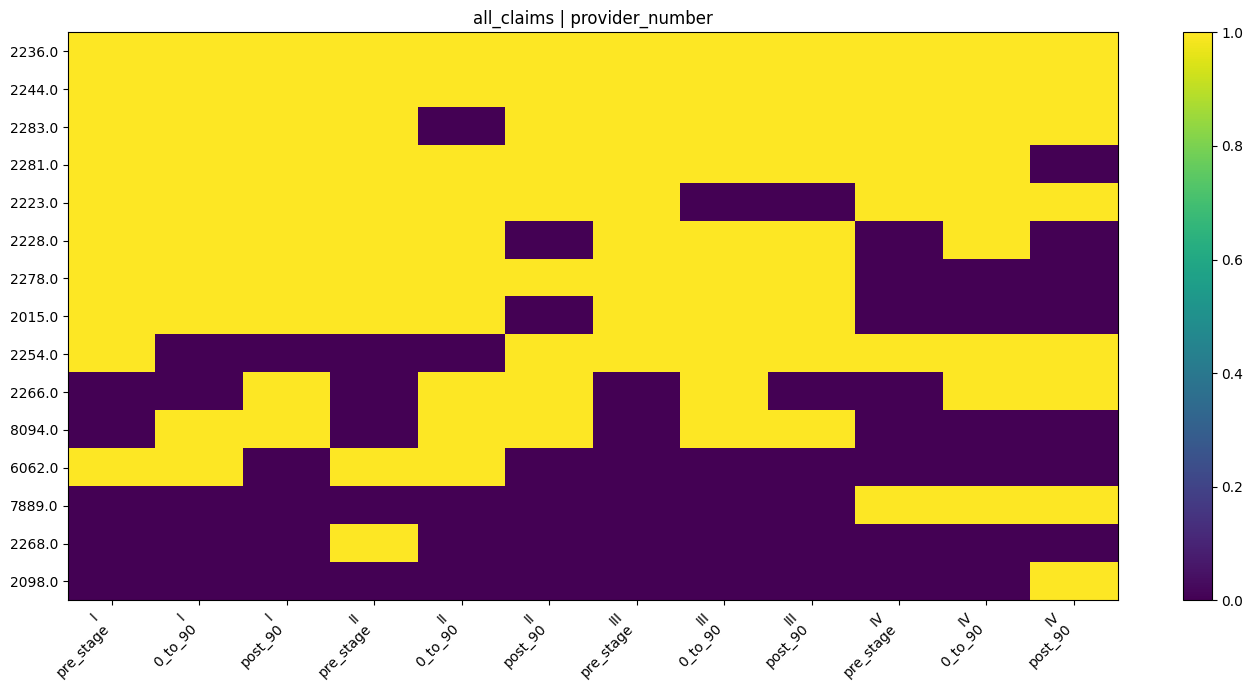

final_stage_simple             I                        II                  \
stage_time_window      pre_stage 0_to_90 post_90 pre_stage 0_to_90 post_90   
DRUG_NM                                                                      
LETROZOLE                    Yes     Yes     Yes       Yes     Yes     Yes   
ANASTROZOLE                  Yes     Yes     Yes       Yes      No     Yes   
EXEMESTANE                   Yes     Yes     Yes       Yes      No     Yes   
PROCHLORPERAZINE MALEA       Yes     Yes      No       Yes     Yes      No   
VERZENIO                     Yes     Yes     Yes        No      No     Yes   
IBRANCE                       No      No      No        No      No     Yes   
CAPECITABINE                  No     Yes      No       Yes     Yes     Yes   
TAMOXIFEN CITRATE            Yes     Yes     Yes       Yes     Yes     Yes   
DEXAMETHASONE                Yes     Yes      No       Yes     Yes      No   
POTASSIUM CHLORIDE            No      No      No       Yes     Yes     Yes   
LIDOCAINE-PRILOCAINE         Yes     Yes      No        No      No      No   
MORPHINE SULFATE ER           No      No      No        No      No      No   
NEUPOGEN                      No      No      No        No     Yes     Yes   
KISQALI                       No      No     Yes        No      No      No   
ELIQUIS                       No      No      No        No      No     Yes   

final_stage_simple           III                        IV                  \
stage_time_window      pre_stage 0_to_90 post_90 pre_stage 0_to_90 post_90   
DRUG_NM                                                                      
LETROZOLE                    Yes     Yes     Yes       Yes     Yes     Yes   
ANASTROZOLE                  Yes     Yes     Yes       Yes     Yes     Yes   
EXEMESTANE                   Yes     Yes     Yes       Yes     Yes     Yes   
PROCHLORPERAZINE MALEA       Yes     Yes     Yes       Yes     Yes      No   
VERZENIO                      No      No     Yes       Yes     Yes     Yes   
IBRANCE                      Yes     Yes     Yes       Yes     Yes     Yes   
CAPECITABINE                  No      No     Yes        No     Yes     Yes   
TAMOXIFEN CITRATE            Yes      No      No        No      No      No   
DEXAMETHASONE                Yes     Yes      No        No      No      No   
POTASSIUM CHLORIDE            No      No      No        No      No      No   
LIDOCAINE-PRILOCAINE          No     Yes      No        No      No      No   
MORPHINE SULFATE ER           No      No      No       Yes     Yes      No   
NEUPOGEN                      No      No      No        No      No      No   
KISQALI                       No      No      No        No     Yes      No   
ELIQUIS                       No      No      No        No      No     Yes   

final_stage_simple     n_hits  
stage_time_window              
DRUG_NM                        
LETROZOLE                12.0  
ANASTROZOLE              11.0  
EXEMESTANE               11.0  
PROCHLORPERAZINE MALEA    9.0  
VERZENIO                  8.0  
IBRANCE                   7.0  
CAPECITABINE              7.0  
TAMOXIFEN CITRATE         7.0  
DEXAMETHASONE             6.0  
POTASSIUM CHLORIDE        3.0  
LIDOCAINE-PRILOCAINE      3.0  
MORPHINE SULFATE ER       2.0  
NEUPOGEN                  2.0  
KISQALI                   2.0  
ELIQUIS                   2.0

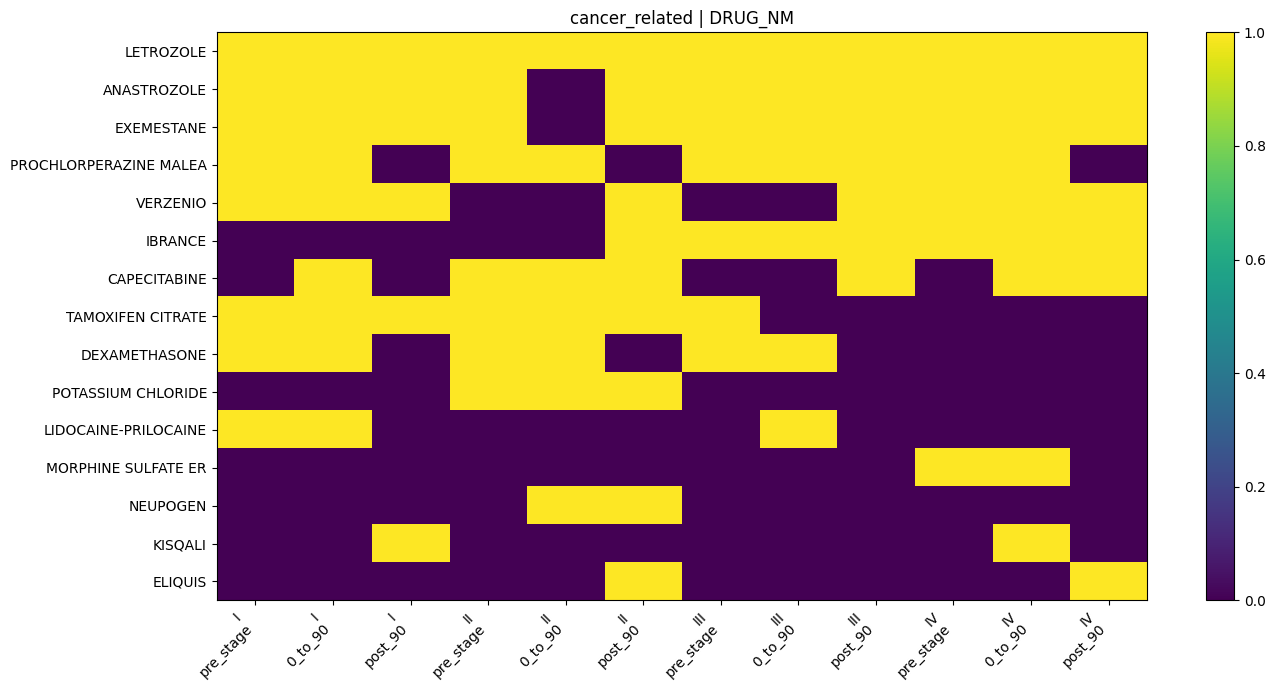

final_stage_simple         I                        II                  \
stage_time_window  pre_stage 0_to_90 post_90 pre_stage 0_to_90 post_90   
HCPCS                                                                    
J9355                    Yes     Yes     Yes       Yes     Yes     Yes   
J9306                    Yes     Yes     Yes       Yes     Yes     Yes   
J2505                    Yes     Yes     Yes       Yes     Yes     Yes   
96413                     No      No     Yes       Yes     Yes     Yes   
J9271                     No      No     Yes       Yes     Yes     Yes   
36561                     No     Yes      No       Yes     Yes      No   
J9354                     No      No     Yes        No      No     Yes   
J9264                     No      No      No        No      No      No   
J0897                     No      No      No        No      No      No   
78815                     No      No      No       Yes      No      No   
J2506                     No      No      No        No     Yes      No   
J9395                     No      No      No        No      No      No   
38525                    Yes     Yes      No       Yes      No      No   
77334                     No     Yes      No        No     Yes      No   
J1950                     No      No     Yes        No      No     Yes   

final_stage_simple       III                        IV                 n_hits  
stage_time_window  pre_stage 0_to_90 post_90 pre_stage 0_to_90 post_90         
HCPCS                                                                          
J9355                    Yes     Yes     Yes       Yes     Yes     Yes   12.0  
J9306                    Yes     Yes     Yes       Yes     Yes     Yes   12.0  
J2505                    Yes     Yes      No       Yes     Yes      No   10.0  
96413                    Yes     Yes     Yes       Yes     Yes     Yes   10.0  
J9271                    Yes     Yes     Yes       Yes      No      No    8.0  
36561                    Yes     Yes      No        No     Yes      No    6.0  
J9354                    Yes      No     Yes       Yes      No     Yes    6.0  
J9264                    Yes     Yes     Yes       Yes      No     Yes    5.0  
J0897                     No      No     Yes       Yes     Yes     Yes    4.0  
78815                    Yes      No      No       Yes     Yes      No    4.0  
J2506                    Yes     Yes      No        No      No      No    3.0  
J9395                     No      No      No       Yes     Yes     Yes    3.0  
38525                     No      No      No        No      No      No    3.0  
77334                     No     Yes      No        No      No      No    3.0  
J1950                     No      No     Yes        No      No      No    3.0

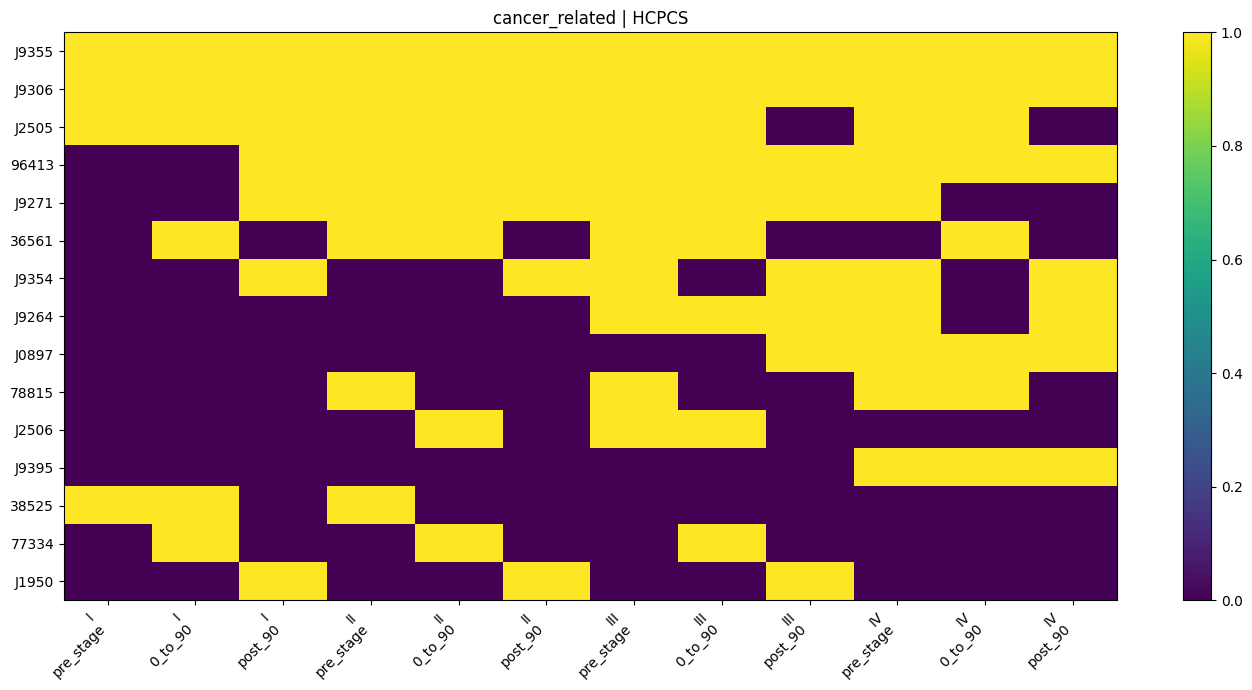

final_stage_simple                   I                        II          \
stage_time_window            pre_stage 0_to_90 post_90 pre_stage 0_to_90   
PROC_DESC                                                                  
INJECTION, PERTUZUMAB, 1 MG        Yes     Yes     Yes       Yes     Yes   
TRASTUZUMAB INJECTION              Yes     Yes     Yes       Yes     Yes   
INJECTION, PEGFILGRASTIM 6MG       Yes     Yes     Yes       Yes     Yes   
CHEMO IV INFUSION 1 HR              No      No     Yes       Yes     Yes   
RADIATION TREATMENT DELIVERY       Yes     Yes     Yes       Yes     Yes   
INJ PEMBROLIZUMAB                   No      No     Yes       Yes     Yes   
INJ, ADO-TRASTUZUMAB EMT 1MG        No      No     Yes        No      No   
INSERT TUNNELED CV CATH             No     Yes      No       Yes     Yes   
PET IMAGE W/CT SKULL-THIGH          No      No      No       Yes      No   
PACLITAXEL PROTEIN BOUND            No      No      No        No      No   
DENOSUMAB INJECTION                 No      No      No        No      No   
LEUPROLIDE ACETATE /3.75 MG         No      No     Yes        No      No   
BREAST RECONSTRUCTION              Yes      No      No        No      No   
BIOPSY/REMOVAL LYMPH NODES         Yes     Yes      No       Yes      No   
INJECTION, FULVESTRANT              No      No      No        No      No   

final_stage_simple                         III                        IV  \
stage_time_window            post_90 pre_stage 0_to_90 post_90 pre_stage   
PROC_DESC                                                                  
INJECTION, PERTUZUMAB, 1 MG      Yes       Yes     Yes     Yes       Yes   
TRASTUZUMAB INJECTION            Yes       Yes     Yes     Yes       Yes   
INJECTION, PEGFILGRASTIM 6MG     Yes       Yes     Yes      No       Yes   
CHEMO IV INFUSION 1 HR           Yes       Yes     Yes     Yes       Yes   
RADIATION TREATMENT DELIVERY     Yes        No     Yes     Yes        No   
INJ PEMBROLIZUMAB                Yes       Yes     Yes     Yes       Yes   
INJ, ADO-TRASTUZUMAB EMT 1MG     Yes       Yes      No     Yes       Yes   
INSERT TUNNELED CV CATH           No       Yes     Yes      No        No   
PET IMAGE W/CT SKULL-THIGH        No       Yes      No      No       Yes   
PACLITAXEL PROTEIN BOUND          No       Yes     Yes     Yes       Yes   
DENOSUMAB INJECTION               No        No      No     Yes       Yes   
LEUPROLIDE ACETATE /3.75 MG      Yes        No      No     Yes        No   
BREAST RECONSTRUCTION            Yes        No      No     Yes        No   
BIOPSY/REMOVAL LYMPH NODES        No        No      No      No        No   
INJECTION, FULVESTRANT            No        No      No      No       Yes   

final_stage_simple                           n_hits  
stage_time_window            0_to_90 post_90         
PROC_DESC                                            
INJECTION, PERTUZUMAB, 1 MG      Yes     Yes   12.0  
TRASTUZUMAB INJECTION            Yes     Yes   12.0  
INJECTION, PEGFILGRASTIM 6MG     Yes      No   10.0  
CHEMO IV INFUSION 1 HR           Yes     Yes   10.0  
RADIATION TREATMENT DELIVERY     Yes      No    9.0  
INJ PEMBROLIZUMAB                 No      No    8.0  
INJ, ADO-TRASTUZUMAB EMT 1MG      No     Yes    6.0  
INSERT TUNNELED CV CATH          Yes      No    6.0  
PET IMAGE W/CT SKULL-THIGH       Yes     Yes    5.0  
PACLITAXEL PROTEIN BOUND          No     Yes    5.0  
DENOSUMAB INJECTION              Yes     Yes    4.0  
LEUPROLIDE ACETATE /3.75 MG       No      No    3.0  
BREAST RECONSTRUCTION             No      No    3.0  
BIOPSY/REMOVAL LYMPH NODES        No      No    3.0  
INJECTION, FULVESTRANT           Yes     Yes    3.0

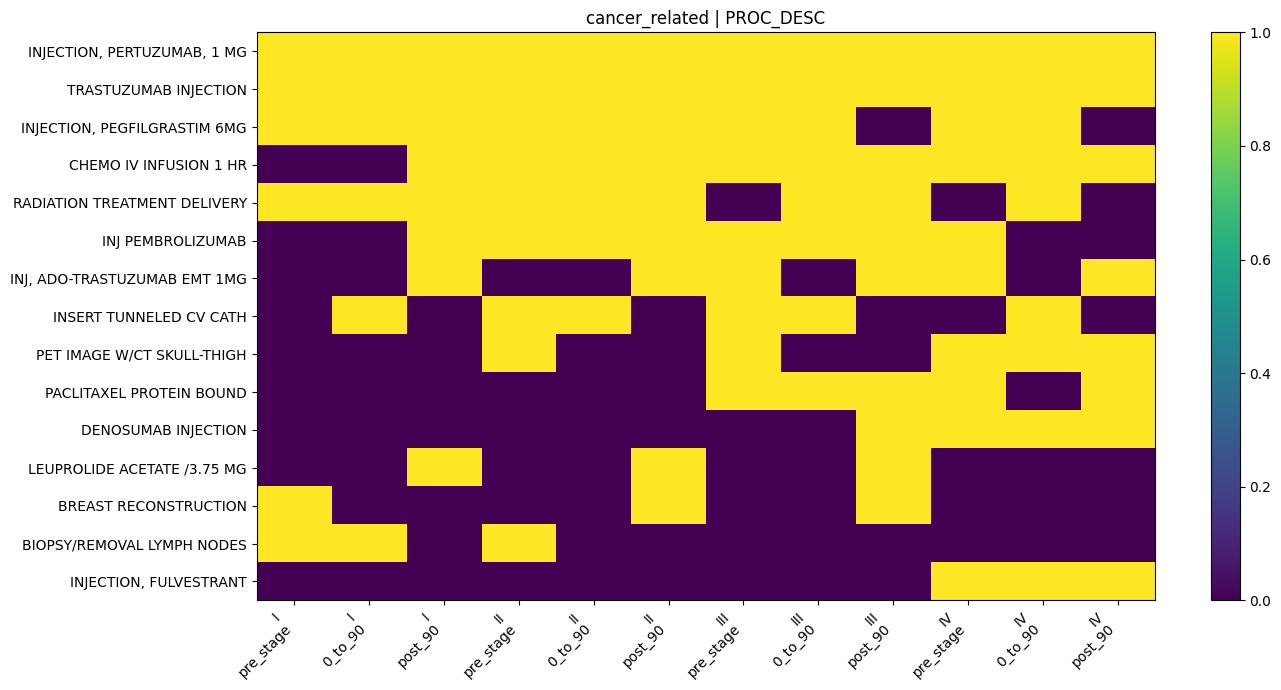

final_stage_simple         I                        II                  \
stage_time_window  pre_stage 0_to_90 post_90 pre_stage 0_to_90 post_90   
provider_number                                                          
2283.0                   Yes     Yes     Yes       Yes     Yes     Yes   
2236.0                   Yes     Yes     Yes       Yes     Yes     Yes   
2244.0                   Yes     Yes     Yes       Yes     Yes     Yes   
2281.0                   Yes     Yes     Yes       Yes     Yes     Yes   
2223.0                   Yes     Yes     Yes       Yes     Yes     Yes   
2015.0                   Yes     Yes     Yes       Yes     Yes      No   
2254.0                   Yes      No     Yes        No      No      No   
2278.0                   Yes     Yes     Yes       Yes     Yes     Yes   
2228.0                    No     Yes     Yes       Yes     Yes      No   
8094.0                   Yes     Yes      No        No     Yes     Yes   
6062.0                   Yes     Yes      No       Yes     Yes      No   
7889.0                    No      No      No        No      No      No   
2282.0                    No      No     Yes        No      No      No   
2266.0                    No      No      No        No      No     Yes   
7996.0                    No      No      No        No      No      No   

final_stage_simple       III                        IV                 n_hits  
stage_time_window  pre_stage 0_to_90 post_90 pre_stage 0_to_90 post_90         
provider_number                                                                
2283.0                   Yes     Yes     Yes       Yes     Yes     Yes   12.0  
2236.0                   Yes     Yes     Yes       Yes     Yes     Yes   12.0  
2244.0                   Yes     Yes     Yes       Yes     Yes     Yes   12.0  
2281.0                   Yes     Yes     Yes       Yes     Yes      No   11.0  
2223.0                   Yes      No      No       Yes     Yes     Yes   10.0  
2015.0                   Yes     Yes     Yes        No      No      No    8.0  
2254.0                   Yes     Yes     Yes       Yes     Yes     Yes    8.0  
2278.0                   Yes     Yes      No        No      No      No    8.0  
2228.0                   Yes     Yes      No        No     Yes      No    7.0  
8094.0                    No     Yes      No        No      No      No    5.0  
6062.0                    No      No      No        No      No      No    4.0  
7889.0                    No      No      No       Yes     Yes     Yes    3.0  
2282.0                    No      No     Yes        No      No     Yes    3.0  
2266.0                    No      No      No        No     Yes     Yes    3.0  
7996.0                    No      No     Yes       Yes      No      No    2.0

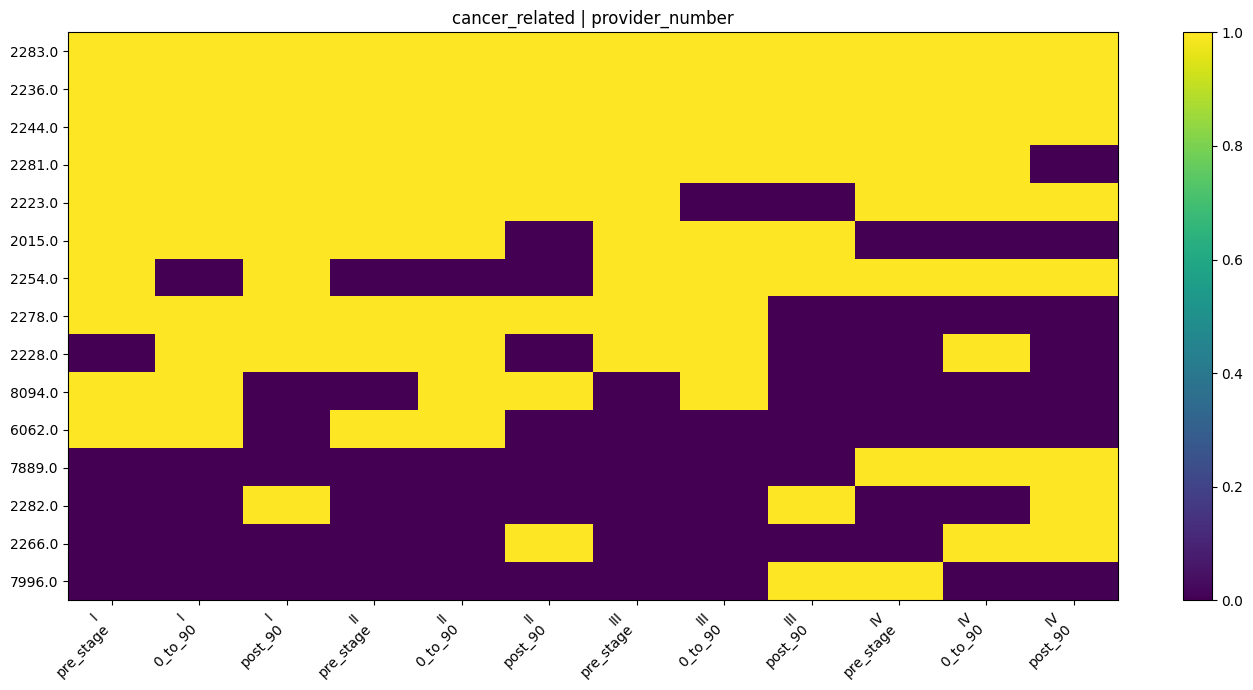

In [ ]:
for cohort in ["all_claims", "cancer_related"]:
    for col in driver_cols:
        mat_num, mat_yesno = make_presence_matrix(time_aware[cohort][col], col)
        display(mat_yesno.head(15))
        plot_heatmap(mat_num, title=f"{cohort} | {col}", top_n=15, figsize=(14, 7))

5. Combinations and Interaction Effects

In [22]:
# Stage II subset
stage2_all = breast[breast["final_stage_simple"] == "II"].copy()
stage2_cancer = breast[
    (breast["final_stage_simple"] == "II") &
    (breast["is_cancer_related"] == True)
].copy()

print("Stage II all claims:", stage2_all.shape, "patients:", stage2_all["member_number"].nunique())
print("Stage II cancer-related claims:", stage2_cancer.shape, "patients:", stage2_cancer["member_number"].nunique())

Stage II all claims: (276147, 31) patients: 375
Stage II cancer-related claims: (124465, 31) patients: 375


In [23]:
def patient_value_sets(df, col):
    temp = df.copy()
    temp[col] = temp[col].astype(str).str.strip()
    temp = temp[
        temp[col].notna() &
        (temp[col] != "") &
        (temp[col].str.upper() != "NAN")
    ].copy()

    return (
        temp.groupby("member_number")[col]
        .apply(lambda x: sorted(set(x)))
        .to_dict()
    )

In [24]:
from itertools import product

def summarize_pair_combos(df, col1, col2, min_patients=5):
    # patient-level total cost in this slice
    patient_costs = (
        df.groupby("member_number")
        .agg(
            patient_total_cost=("c_allowed", "sum"),
            patient_total_claims=("member_number", "size"),
            patient_total_util=("C_UTIL_CT", "sum")
        )
        .reset_index()
    )

    # unique values per patient for each column
    vals1 = patient_value_sets(df, col1)
    vals2 = patient_value_sets(df, col2)

    rows = []
    patients = sorted(set(patient_costs["member_number"]))

    for pid in patients:
        a = vals1.get(pid, [])
        b = vals2.get(pid, [])

        for v1, v2 in product(a, b):
            rows.append({
                "member_number": pid,
                col1: v1,
                col2: v2
            })

    pair_df = pd.DataFrame(rows)

    if pair_df.empty:
        return pair_df

    out = (
        pair_df.merge(patient_costs, on="member_number", how="left")
        .groupby([col1, col2])
        .agg(
            n_patients=("member_number", "nunique"),
            total_patient_cost=("patient_total_cost", "sum"),
            mean_patient_cost=("patient_total_cost", "mean"),
            median_patient_cost=("patient_total_cost", "median"),
            mean_patient_claims=("patient_total_claims", "mean"),
            mean_patient_util=("patient_total_util", "mean")
        )
        .reset_index()
    )

    out = out[out["n_patients"] >= min_patients].copy()
    out = out.sort_values(
        ["total_patient_cost", "n_patients"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return out

In [25]:
pair_cols = ["DRUG_NM", "HCPCS", "PROC_DESC", "provider_number"]

pair_results_stage2_cancer = {}
pair_results_stage2_all = {}

for i in range(len(pair_cols)):
    for j in range(i + 1, len(pair_cols)):
        c1, c2 = pair_cols[i], pair_cols[j]

        pair_results_stage2_cancer[(c1, c2)] = summarize_pair_combos(
            stage2_cancer, c1, c2, min_patients=5
        )

        pair_results_stage2_all[(c1, c2)] = summarize_pair_combos(
            stage2_all, c1, c2, min_patients=5
        )

In [30]:
for pair_name, df_out in pair_results_stage2_cancer.items():
    print(f"\nStage II cancer-related | {pair_name}")
    display(df_out.head(10))


Stage II cancer-related | ('DRUG_NM', 'HCPCS')


,DRUG_NM,HCPCS,n_patients,total_patient_cost,mean_patient_cost,median_patient_cost,mean_patient_claims,mean_patient_util
0,PROCHLORPERAZINE MALEA,36415,48,1.148791e+07,239331.448323,165679.739834,533.312500,510.927507
1,PROCHLORPERAZINE MALEA,80053,48,1.148791e+07,239331.448323,165679.739834,533.312500,510.927507
2,PROCHLORPERAZINE MALEA,83735,48,1.148791e+07,239331.448323,165679.739834,533.312500,510.927507
3,PROCHLORPERAZINE MALEA,85025,48,1.148791e+07,239331.448323,165679.739834,533.312500,510.927507
4,PROCHLORPERAZINE MALEA,88305,47,1.147522e+07,244153.633935,167854.711009,542.106383,520.493652
5,PROCHLORPERAZINE MALEA,J2250,46,1.137380e+07,247256.508554,168016.275474,546.173913,527.934597
6,PROCHLORPERAZINE MALEA,J3010,46,1.137380e+07,247256.508554,168016.275474,546.173913,527.934597
7,PROCHLORPERAZINE MALEA,96375,45,1.135606e+07,252356.841019,168177.839939,549.333333,498.371555
8,PROCHLORPERAZINE MALEA,J7050,45,1.134958e+07,252212.883803,168177.839939,549.000000,489.124735
9,PROCHLORPERAZINE MALEA,96413,44,1.129168e+07,256629.070590,171896.976880,555.318182,496.897675



Stage II cancer-related | ('DRUG_NM', 'PROC_DESC')


,DRUG_NM,PROC_DESC,n_patients,total_patient_cost,mean_patient_cost,median_patient_cost,mean_patient_claims,mean_patient_util
0,PROCHLORPERAZINE MALEA,ASSAY OF MAGNESIUM,48,1.148791e+07,239331.448323,165679.739834,533.312500,510.927507
1,PROCHLORPERAZINE MALEA,COMPLETE CBC W/AUTO DIFF WBC,48,1.148791e+07,239331.448323,165679.739834,533.312500,510.927507
2,PROCHLORPERAZINE MALEA,COMPREHEN METABOLIC PANEL,48,1.148791e+07,239331.448323,165679.739834,533.312500,510.927507
3,PROCHLORPERAZINE MALEA,OFFICE/OUTPATIENT VISIT EST,48,1.148791e+07,239331.448323,165679.739834,533.312500,510.927507
4,PROCHLORPERAZINE MALEA,ROUTINE VENIPUNCTURE,48,1.148791e+07,239331.448323,165679.739834,533.312500,510.927507
5,PROCHLORPERAZINE MALEA,OFFICE/OUTPATIENT VISIT NEW,47,1.147522e+07,244153.633935,167854.711009,542.106383,520.493652
6,PROCHLORPERAZINE MALEA,TISSUE EXAM BY PATHOLOGIST,47,1.147522e+07,244153.633935,167854.711009,542.106383,520.493652
7,PROCHLORPERAZINE MALEA,FENTANYL CITRATE INJECTION,46,1.137380e+07,247256.508554,168016.275474,546.173913,527.934597
8,PROCHLORPERAZINE MALEA,INJ MIDAZOLAM HYDROCHLORIDE,46,1.137380e+07,247256.508554,168016.275474,546.173913,527.934597
9,PROCHLORPERAZINE MALEA,TX/PRO/DX INJ NEW DRUG ADDON,45,1.135606e+07,252356.841019,168177.839939,549.333333,498.371555



Stage II cancer-related | ('DRUG_NM', 'provider_number')


...

,HCPCS,PROC_DESC,n_patients,total_patient_cost,mean_patient_cost,median_patient_cost,mean_patient_claims,mean_patient_util
0,80053,COMPREHEN METABOLIC PANEL,358,4.514638e+07,126107.205228,70423.862076,346.561453,283.832500
1,80053,OFFICE/OUTPATIENT VISIT EST,355,4.500359e+07,126770.670305,71356.445953,349.109859,286.074517
2,85025,COMPLETE CBC W/AUTO DIFF WBC,355,4.499282e+07,126740.337178,71356.445953,348.521127,283.103850
3,80053,COMPLETE CBC W/AUTO DIFF WBC,354,4.499151e+07,127094.658935,71429.890689,349.474576,283.889068
4,85025,COMPREHEN METABOLIC PANEL,354,4.499151e+07,127094.658935,71429.890689,349.474576,283.889068
5,85025,OFFICE/OUTPATIENT VISIT EST,352,4.485003e+07,127414.852798,71429.890689,351.107955,285.358766
6,36415,ROUTINE VENIPUNCTURE,352,4.483681e+07,127377.295887,71649.545833,350.730114,291.063288
7,36415,COMPREHEN METABOLIC PANEL,347,4.479992e+07,129106.407213,73035.455864,354.994236,291.271983
8,80053,ROUTINE VENIPUNCTURE,347,4.479992e+07,129106.407213,73035.455864,354.994236,291.271983
9,36415,OFFICE/OUTPATIENT VISIT EST,349,4.469402e+07,128063.084925,71795.756241,353.358166,293.406005



Stage II cancer-related | ('HCPCS', 'provider_number')


,HCPCS,provider_number,n_patients,total_patient_cost,mean_patient_cost,median_patient_cost,mean_patient_claims,mean_patient_util
0,85025,2244.0,294,4.123068e+07,140240.405082,83451.226791,377.731293,291.194457
1,80053,2244.0,293,4.122937e+07,140714.568802,83524.569176,378.982935,292.170764
2,36415,2244.0,289,4.109179e+07,142186.140003,85755.623390,382.847751,299.693840
3,99214,2244.0,285,4.050626e+07,142127.233956,85547.723352,384.400000,302.535693
4,88305,2244.0,241,4.018745e+07,166752.894874,103609.690000,437.087137,334.482821
5,J3010,2244.0,232,3.987297e+07,171866.270331,110542.414811,450.629310,338.397096
6,J2250,2244.0,223,3.947167e+07,177002.995092,112099.592608,461.695067,347.106564
7,83735,2244.0,219,3.921279e+07,179053.817348,121908.770000,464.634703,334.996744
8,G0463,2244.0,274,3.907002e+07,142591.316718,85812.948003,383.875912,286.090290
9,J7050,2244.0,194,3.856223e+07,198774.363999,137036.990561,504.752577,344.655520



Stage II cancer-related | ('PROC_DESC', 'provider_number')


,PROC_DESC,provider_number,n_patients,total_patient_cost,mean_patient_cost,median_patient_cost,mean_patient_claims,mean_patient_util
0,COMPLETE CBC W/AUTO DIFF WBC,2244.0,294,4.123068e+07,140240.405082,83451.226791,377.731293,291.194457
1,COMPREHEN METABOLIC PANEL,2244.0,293,4.122937e+07,140714.568802,83524.569176,378.982935,292.170764
2,OFFICE/OUTPATIENT VISIT EST,2244.0,297,4.120488e+07,138736.972596,82538.224084,374.080808,292.527368
3,ROUTINE VENIPUNCTURE,2244.0,289,4.109179e+07,142186.140003,85755.623390,382.847751,299.693840
4,TISSUE EXAM BY PATHOLOGIST,2244.0,246,4.070883e+07,165483.033640,103485.435000,436.796748,330.771551
5,OFFICE/OUTPATIENT VISIT NEW,2244.0,247,4.033744e+07,163309.464339,102032.532882,429.372470,326.074760
6,FENTANYL CITRATE INJECTION,2244.0,232,3.987297e+07,171866.270331,110542.414811,450.629310,338.397096
7,INJ MIDAZOLAM HYDROCHLORIDE,2244.0,223,3.947167e+07,177002.995092,112099.592608,461.695067,347.106564
8,ASSAY OF MAGNESIUM,2244.0,219,3.921279e+07,179053.817348,121908.770000,464.634703,334.996744
9,HOSPITAL OUTPT CLINIC VISIT,2244.0,274,3.907002e+07,142591.316718,85812.948003,383.875912,286.090290
